# 1. 기온 공공데이터 살펴보기

### 기상자료개방포털: https://data.kma.go.kr 에서 지역별 기온 데이터 내려받기
- 상단 메뉴에서 **기후통계분석** -> **기온분석** 선택

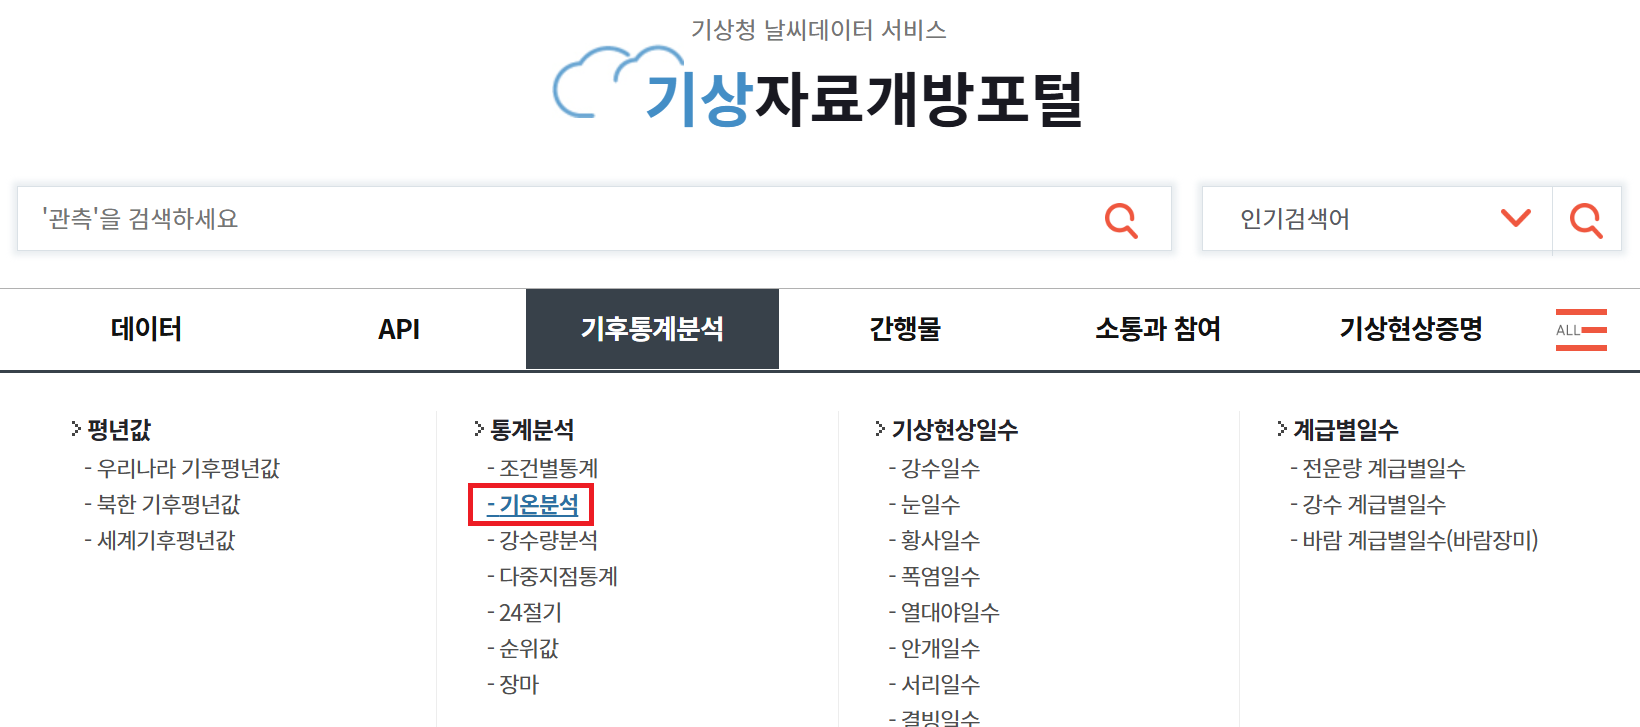

- 내가 태어난 년도부터 현재까지의 데이터를 **검색 조건**에 넣고 검색하기
- 검색 후, **CSV** 버튼을 클릭하여 데이터 다운로드


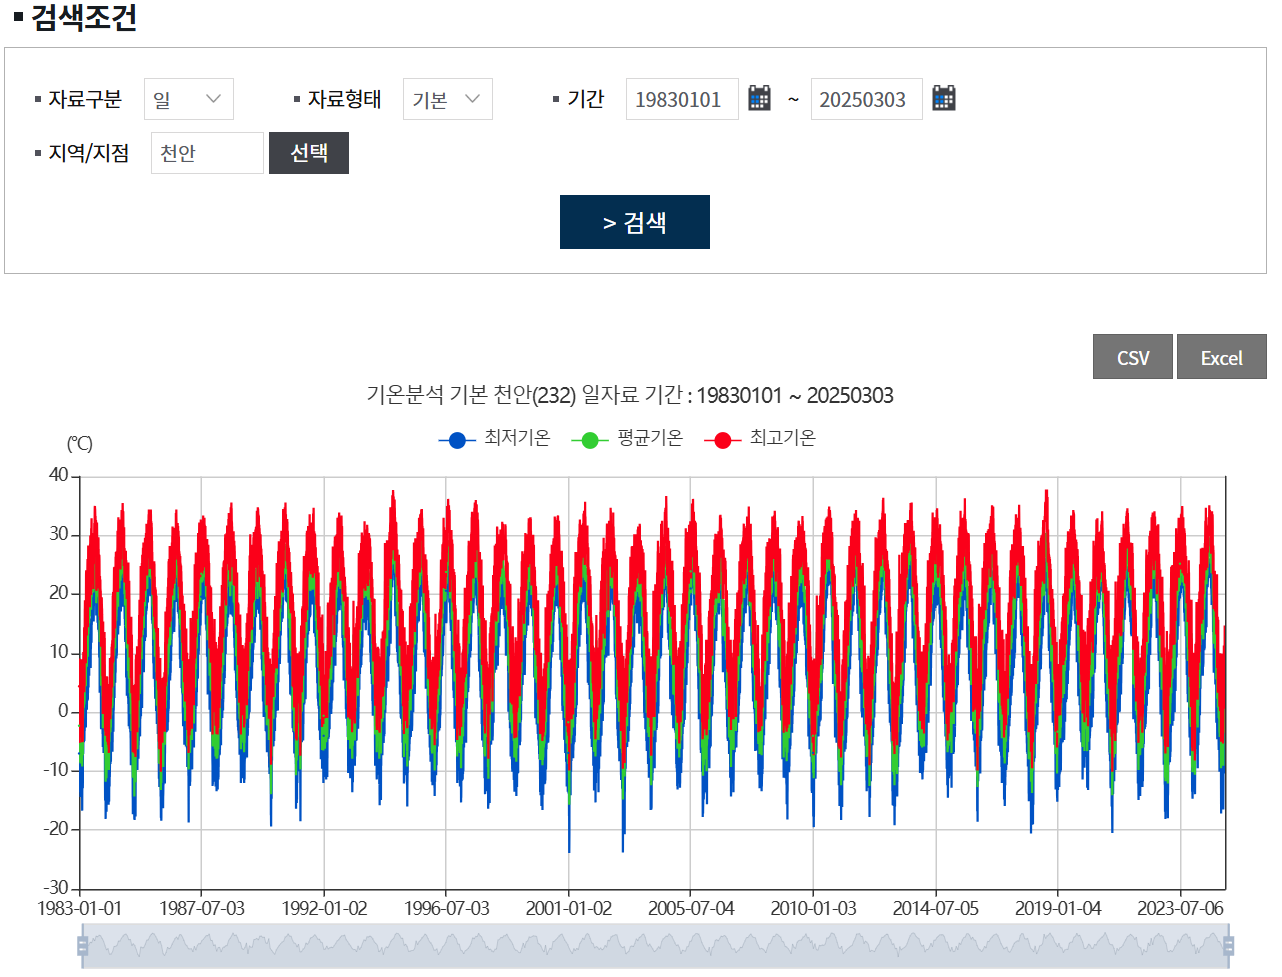


- 다운로드 받은 csv 파일을 열어 윗 부분 지우기

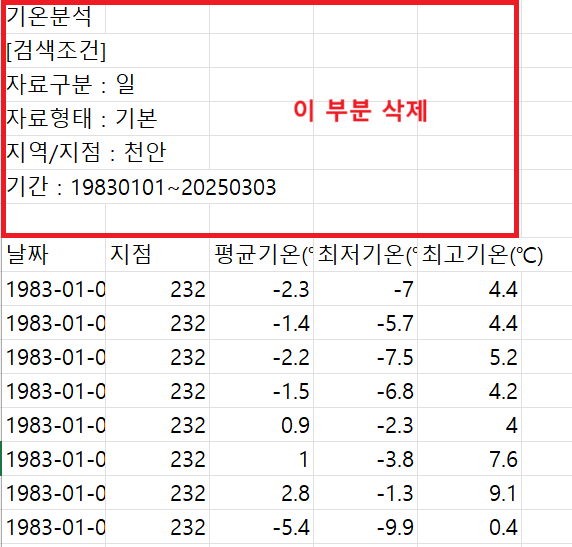

# 2. 데이터에 질문하기
### 2.1 다운로드 받은 csv파일의 이름을 **'3.1.temp.csv'**로 변경 후 업로드

### 2.2 데이터 읽어오기

In [ ]:
import pandas as pd

data = pd.read_csv('3.1.2.temp.csv', encoding='cp949')
data

In [ ]:
# 날짜 앞의 \t 없애기
data['날짜'] = data['날짜'].str.replace('\t', '')

In [ ]:
data.info()

In [ ]:
# 날짜 컬럼의 object 타입을 날짜형식(datetime)으로 변환하기
data['날짜'] = pd.to_datetime(data['날짜'])
data.info()

In [ ]:
data

In [ ]:
# 최고 기온만 날짜와 함께 저장하기
result = data.iloc[:, [0,4]]
result

### 2.3 데이터 시각화 하기

In [ ]:
import matplotlib.pyplot as plt

plt.plot(result['최고기온(℃)'])   # x축 날짜는 생략

In [ ]:
# 내가 태어난 달에 해당하는 기온 데이터만 추출하기
month_result = result[result['날짜'].dt.month == 8]       # 자기가 태어난 달로 바꿔보세요
month_result

In [ ]:
plt.plot(month_result['최고기온(℃)'])   # x축 날짜는 생략

In [ ]:
# 내 생일에 해당하는 온도만 추출
birthday_result = result[(result['날짜'].dt.month == 8) & (result['날짜'].dt.day == 16)]
birthday_result

In [ ]:
plt.plot(birthday_result['최고기온(℃)'])   # x축 날짜는 생략

In [ ]:
# 내 생일의 최저 기온과 최고 기온을 모두 추출하기
birthday_result2 = data[(data['날짜'].dt.month == 8) & (data['날짜'].dt.day == 16)]
birthday_result2

In [ ]:
plt.plot(birthday_result2['최저기온(℃)'])
plt.plot(birthday_result2['최고기온(℃)'])

In [ ]:
# x축 라벨을 추가해서 그리기
plt.plot(birthday_result2['날짜'], birthday_result2['최저기온(℃)'])
plt.plot(birthday_result2['날짜'], birthday_result2['최고기온(℃)'])

In [ ]:
plt.plot(birthday_result2['날짜'], birthday_result2['최저기온(℃)'])
plt.plot(birthday_result2['날짜'], birthday_result2['최고기온(℃)'])
plt.title('내 생일의 기온 변화 그래프')

### 2.4 코랩에서 한글 폰트 사용하기

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

## 런타임 다시 시작한 후 아래 코드 실행

In [ ]:
# 한글 폰트 적용
import matplotlib.font_manager as fm

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False      # - 기호가 깨지는 것을 방지

# 내 생일의 최저 기온과 최고 기온을 모두 추출하기
birthday_result2 = data[(data['날짜'].dt.month == 8) & (data['날짜'].dt.day == 16)]
birthday_result2

plt.plot(birthday_result2['날짜'], birthday_result2['최저기온(℃)'])
plt.plot(birthday_result2['날짜'], birthday_result2['최고기온(℃)'])
plt.title('내 생일의 기온 변화 그래프')